In [1]:
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.


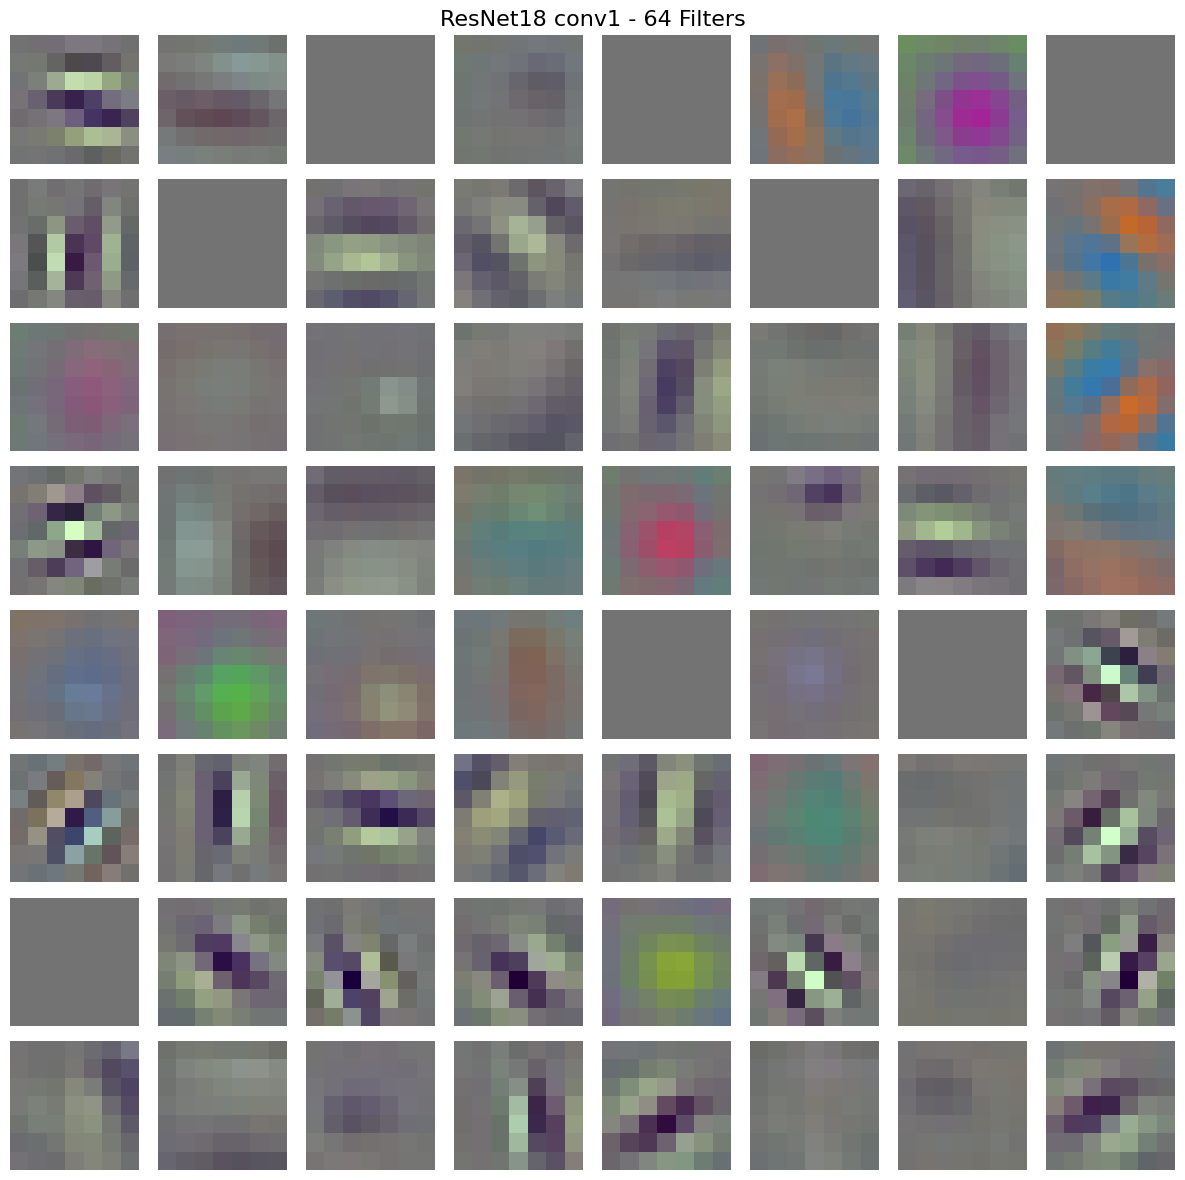

In [2]:
import torch
import torchvision.models as models
import matplotlib.pyplot as plt

# load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# first conv layer
weights = model.conv1.weight.data.clone()  # (64, 3, 7, 7)

# normalize to [0,1] for visualization
weights = (weights - weights.min()) / (weights.max() - weights.min())

# plot 64 filters → 8x8 grid
fig, axes = plt.subplots(8, 8, figsize=(12, 12))

for i in range(64):
    w = weights[i]  # (3,7,7)
    w = w.permute(1, 2, 0)  # (7,7,3)

    ax = axes[i // 8, i % 8]
    ax.imshow(w)
    ax.axis('off')

plt.suptitle("ResNet18 conv1 - 64 Filters", fontsize=16)
plt.tight_layout()
plt.show()

In [3]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
import cv2
img = cv2.imread("image.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = torch.tensor(img, dtype=torch.float32) / 255.0
img = img.permute(2, 0, 1)   # (3,H,W)
img = img.unsqueeze(0)  

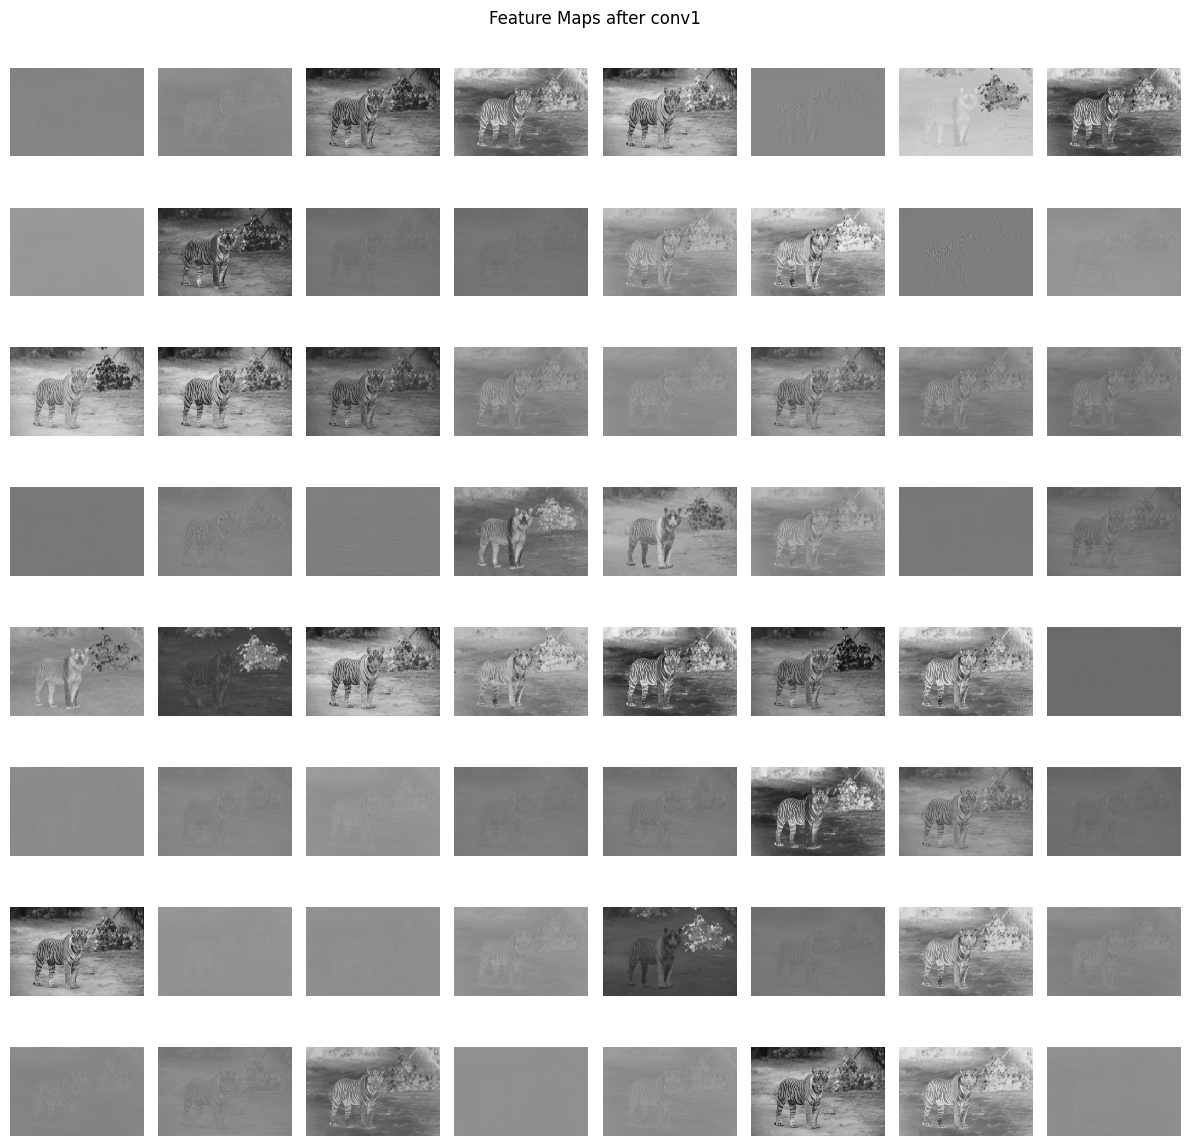

In [5]:
with torch.no_grad():
    x = model.conv1(img)     # (1,64,H/2,W/2)

# ---- Visualize 64 maps ----
fig, axes = plt.subplots(8, 8, figsize=(12, 12))

for i in range(64):
    fmap = x[0, i].cpu()
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min())  # normalize

    ax = axes[i//8, i%8]
    ax.imshow(fmap, cmap='gray')
    ax.axis('off')

plt.suptitle("Feature Maps after conv1")
plt.tight_layout()
plt.show()